# 8-bit 3D VQ (sign+absolute) with INT8 compute

Exploring a format that performs "outer" channel-wise INT8 quantisation for weights and activations, with "inner" 3D vector quantisation of absolute values into 5 bits (32 centroids), and 3 sign bits to make 8 bits per 3 values.

In [ ]:
import copy
import itertools as it
from math import log2
from typing import Any, Callable, Literal

import matplotlib
import matplotlib.pyplot as plt
import PIL.Image
import torch
import tqdm
import transformers
from torch import Tensor, nn
from transformers.models.mllama.modeling_mllama import (
    MllamaCrossAttentionDecoderLayer, MllamaSelfAttentionDecoderLayer)

matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "legend.frameon": True})

model = transformers.MllamaForConditionalGeneration.from_pretrained("meta-llama/Llama-3.2-11B-Vision-Instruct", torch_dtype=torch.bfloat16)
processor = transformers.AutoProcessor.from_pretrained(model.config._name_or_path)
for p in model.parameters():
    p.requires_grad_(False)
qmodel = copy.deepcopy(model)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

## Utilities

In [3]:
def _lloyd_max_init(
    init: Literal["random", "kmeans++"], tensor: Tensor, n_centroids: int
) -> Tensor:
    if init == "random":
        return tensor[:n_centroids].clone()
    elif init == "kmeans++":
        s = tensor[: int(2**20)]
        p = torch.ones_like(s[:, 0])
        centroids = torch.empty((n_centroids, s.shape[1]), device=s.device, dtype=s.dtype)
        step = max(1, n_centroids // 64)
        for i in range(0, n_centroids, step):
            n = min(step, n_centroids - i)
            centroids[i : i + n] = s[torch.multinomial(p / p.sum(), n)]
            idx = torch.cdist(s, centroids[: i + n]).argmin(-1)
            p = (s - centroids[idx]).pow(2).sum(-1)
        return centroids
    else:
        raise ValueError(f"_lloyd_max_init method {init!r} is unknown")


def lloyd_max(
    tensor: Tensor,
    n_centroids: int,
    threshold: float,
    *,
    init: Literal["random", "kmeans++"] = "kmeans++",
    sample_limit: int | None = None,
    incremental: bool = True,
    progress: bool = False,
) -> Tensor:
    """Run Lloyd-Max to train a vector quantiser.

    tensor -- (n, d) -- for a VQ of dimension `d`
    """
    # Preparation: shuffle, cast, init
    _, dim = tensor.shape
    tensor = tensor[torch.randperm(tensor.shape[0], device=tensor.device, dtype=torch.int32)]
    if sample_limit is not None:
        tensor = tensor[:sample_limit]
    tensor = tensor.float()
    centroids = _lloyd_max_init(init, tensor, n_centroids)

    # K-means iteration
    idx = torch.empty(tensor.shape[0], device=tensor.device, dtype=torch.int64)
    last_idx = torch.empty_like(idx)
    n = 2**20 if incremental else tensor.shape[0]
    tqdm_ = tqdm.tqdm(it.count(), disable=not progress)
    for _ in tqdm_:
        last_idx[:n] = idx[:n]
        idx[:n] = torch.cdist(tensor[:n], centroids).argmin(-1)
        centroids.scatter_reduce_(
            0, idx[:n, None].expand(-1, dim), tensor[:n], "mean", include_self=False,
        )
        idx_change = (last_idx[:n] != idx[:n]).float().mean().item()
        tqdm_.set_postfix_str(f"{idx_change:.1e}")
        if idx_change <= threshold:
            if tensor.nelement() <= n:
                break
            n *= 2
    return centroids


def nearest_idx(tensor: Tensor, centroids: Tensor, max_bytes: int = 8 * 2**30) -> Tensor:
    out = torch.empty(tensor.shape[0], dtype=torch.int64, device=tensor.device)
    chunk_size = int(max_bytes / (centroids.element_size() * centroids.shape[0]))
    for i in range(0, tensor.shape[0], chunk_size):
        chunk = slice(i, min(tensor.shape[0], i + chunk_size))
        torch.argmin(
            torch.cdist(tensor[chunk].to(centroids.dtype), centroids),
            -1,
            out=out[chunk],
        )
    return out


def rmse_norm(ref: Tensor, q: Tensor) -> Tensor:
    return (ref - q).pow(2).mean().div(ref.pow(2).mean()).sqrt()

## Quantisation

In [ ]:
def rotate_residual_stream(m: nn.Module) -> None:
    """Fuse RMSNorm weights and rotate the residual stream with a random orthogonal matrix."""
    hidden_size = m.config.text_config.hidden_size
    rotation = torch.nn.init.orthogonal_(torch.empty(hidden_size, hidden_size, device=m.device)).to(m.dtype)

    # Note: transposes are the opposite of what's expected (except for `embed_tokens`), as PyTorch uses `input @ weight.T`
    m.language_model.model.embed_tokens.weight.copy_(m.language_model.model.embed_tokens.weight @ rotation)
    m.language_model.lm_head.weight.copy_((m.language_model.lm_head.weight * m.language_model.model.norm.weight[None, :]) @ rotation)
    m.language_model.model.norm.weight.fill_(1)
    for layer in m.language_model.model.layers:
        if isinstance(layer, MllamaSelfAttentionDecoderLayer):
            attn_norm = layer.input_layernorm.weight
            layer.self_attn.q_proj.weight.copy_((layer.self_attn.q_proj.weight * attn_norm[None, :]) @ rotation)
            layer.self_attn.k_proj.weight.copy_((layer.self_attn.k_proj.weight * attn_norm[None, :]) @ rotation)
            layer.self_attn.v_proj.weight.copy_((layer.self_attn.v_proj.weight * attn_norm[None, :]) @ rotation)
            layer.self_attn.o_proj.weight.copy_(rotation.T @ layer.self_attn.o_proj.weight)
            layer.input_layernorm.weight.fill_(1)
            mlp_norm = layer.post_attention_layernorm.weight
            layer.mlp.gate_proj.weight.copy_((layer.mlp.gate_proj.weight * mlp_norm[None, :]) @ rotation)
            layer.mlp.up_proj.weight.copy_((layer.mlp.up_proj.weight * mlp_norm[None, :]) @ rotation)
            layer.mlp.down_proj.weight.copy_(rotation.T @ layer.mlp.down_proj.weight)
            layer.post_attention_layernorm.weight.fill_(1)
        elif isinstance(layer, MllamaCrossAttentionDecoderLayer):
            attn_norm = layer.input_layernorm.weight
            layer.cross_attn.q_proj.weight.copy_((layer.cross_attn.q_proj.weight * attn_norm[None, :]) @ rotation)
            layer.cross_attn.k_proj.weight.copy_(layer.cross_attn.k_proj.weight)
            layer.cross_attn.v_proj.weight.copy_(layer.cross_attn.v_proj.weight)
            layer.cross_attn.o_proj.weight.copy_(rotation.T @ layer.cross_attn.o_proj.weight)
            layer.input_layernorm.weight.fill_(1)
            mlp_norm = layer.post_attention_layernorm.weight
            layer.mlp.gate_proj.weight.copy_((layer.mlp.gate_proj.weight * mlp_norm[None, :]) @ rotation)
            layer.mlp.up_proj.weight.copy_((layer.mlp.up_proj.weight * mlp_norm[None, :]) @ rotation)
            layer.mlp.down_proj.weight.copy_(rotation.T @ layer.mlp.down_proj.weight)
            layer.post_attention_layernorm.weight.fill_(1)
        else:
            assert False, f"Unexpected layer type: {type(layer)}"


def quantiser(size: Callable[[Tensor], int]) -> Any:
    def decorator(func: Any) -> Any:
        def func_(tensor: Tensor, **args: Any) -> Tensor:
            quantised = func(tensor, **args)
            tensor._rmsen = rmse_norm(tensor, quantised)
            tensor._size_bits = size(tensor, **args)
            tensor.copy_(quantised)
            return quantised
        func.quantise_ = func_
        return func
    return decorator


@quantiser(size=lambda t: 16 * t.size(0) + 8 * t.numel())
def quantise_channel_int8(tensor: Tensor) -> Tensor:
    scale = tensor.abs().amax(dim=1, keepdim=True).div(127)
    quantised = tensor.div(scale).round().clamp(-128, 127).to(torch.int8)
    return quantised.to(tensor.dtype).mul(scale)


@quantiser(size=lambda t, n_centroids: 16 * t.size(0) + int(log2(n_centroids) * t.numel()))
def quantise_lm_1d(tensor: Tensor, n_centroids: int) -> Tensor:
    # First, channel-wise int8
    scale = tensor.abs().amax(dim=1, keepdim=True).div(127)
    q_i8 = tensor.div(scale).round().clamp(-128, 127).float()
    # Second, 1D k-means
    centroids = lloyd_max(q_i8.view(-1, 1), n_centroids, threshold=1e-3, sample_limit=2**22)
    quantised_v = centroids[nearest_idx(q_i8.view(-1, 1), centroids)].view(tensor.shape)
    return quantised_v.to(tensor.dtype).mul(scale)


@quantiser(size=lambda t: 16 * t.size(0) + int(t.size(1) * 8 * (t.size(0) + 2) // 3))
def quantise_lm_3d8(tensor: Tensor) -> Tensor:
    # First, channel-wise int8
    scale = tensor.abs().amax(dim=1, keepdim=True).div(127)
    q_i8 = tensor.div(scale).round().clamp(-128, 127).float()
    # Second, 3D k-means with sign symmetry
    # (note: vectors of 3 are along the first (output) dimension, which is padded)
    qT_pad = nn.functional.pad(q_i8.T, (0, -(tensor.size(0) % -3))).reshape(-1, 3)
    centroids = lloyd_max(qT_pad.abs(), int(2**5), threshold=1e-3, sample_limit=2**22)
    idx = nearest_idx(qT_pad.abs(), centroids)
    signs = 1 - 2 * qT_pad.signbit()
    return (centroids[idx].mul(signs)
            .view(tensor.size(1), -1)[:, :tensor.size(0)].T.reshape(tensor.shape)
            .to(tensor.dtype)
            .mul(scale))


@torch.inference_mode()
def quantise_model(m: nn.Module, q: Any, quantise_inputs: bool = True, **qargs: Any) -> None:
    def _quantise_linear(module: nn.Linear) -> None:
        assert isinstance(module, nn.Linear), f"Expected nn.Linear, got {type(module)}"
        q.quantise_(module.weight, **qargs)
        if quantise_inputs:
            module.register_forward_pre_hook(lambda _, inputs: quantise_channel_int8(inputs[0]))

    q.quantise_(m.language_model.model.embed_tokens.weight, **qargs)
    torch.cuda.empty_cache()
    _quantise_linear(m.language_model.lm_head)
    torch.cuda.empty_cache()
    for layer in m.language_model.model.layers:
        if isinstance(layer, MllamaSelfAttentionDecoderLayer):
            _quantise_linear(layer.self_attn.q_proj)
            _quantise_linear(layer.self_attn.k_proj)
            _quantise_linear(layer.self_attn.v_proj)
            _quantise_linear(layer.self_attn.o_proj)
            _quantise_linear(layer.mlp.gate_proj)
            _quantise_linear(layer.mlp.up_proj)
            _quantise_linear(layer.mlp.down_proj)
        elif isinstance(layer, MllamaCrossAttentionDecoderLayer):
            _quantise_linear(layer.cross_attn.q_proj)
            _quantise_linear(layer.cross_attn.k_proj)
            _quantise_linear(layer.cross_attn.v_proj)
            _quantise_linear(layer.cross_attn.o_proj)
            _quantise_linear(layer.mlp.gate_proj)
            _quantise_linear(layer.mlp.up_proj)
            _quantise_linear(layer.mlp.down_proj)
        else:
            assert False, f"Unexpected layer type: {type(layer)}"
    for layer in it.chain(m.vision_model.transformer.layers, m.vision_model.global_transformer.layers):
        _quantise_linear(layer.self_attn.q_proj)
        _quantise_linear(layer.self_attn.k_proj)
        _quantise_linear(layer.self_attn.v_proj)
        _quantise_linear(layer.self_attn.o_proj)
        _quantise_linear(layer.mlp.fc1)
        _quantise_linear(layer.mlp.fc2)
    torch.cuda.empty_cache()


def model_size_bytes(m: nn.Module) -> float:
    size_bits = 0
    for p in m.parameters():
        if hasattr(p, "_size_bits"):
            size_bits += p._size_bits
        else:
            size_bits += 16 * p.nelement()
    return size_bits / 8


def model_rmse(m: nn.Module) -> float:
    mse_sum, n = 0, 0
    for p in m.parameters():
        if hasattr(p, "_rmsen"):
            mse_sum += p._rmsen.pow(2) * p.nelement()
            n += p.nelement()
    return (mse_sum / n) ** 0.5 if n else 0


def remove_pre_hooks(m: nn.Module) -> None:
    for module in m.modules():
        module._forward_pre_hooks.clear()


# Reset
qmodel.cuda()
qmodel.load_state_dict(model.state_dict())
remove_pre_hooks(qmodel)
# Quantise
rotate_residual_stream(qmodel)
# quantise_model(qmodel, quantise_channel_int8)          # Compressed 19.87 GB -> 10.04 GB (RMSE: 0.0088)
# quantise_model(qmodel, quantise_lm_1d, n_centroids=2)  # Compressed 19.87 GB -> 1.44 GB (RMSE: 0.5664)
# quantise_model(qmodel, quantise_lm_1d, n_centroids=4)  # Compressed 19.87 GB -> 2.67 GB (RMSE: 0.3457)
# quantise_model(qmodel, quantise_lm_1d, n_centroids=6)  # Compressed 19.87 GB -> 3.39 GB (RMSE: 0.2451)
# quantise_model(qmodel, quantise_lm_1d, n_centroids=7)  # Compressed 19.87 GB -> 3.66 GB (RMSE: 0.2002)
quantise_model(qmodel, quantise_lm_3d8)                # Compressed 19.87 GB -> 3.49 GB (RMSE: 0.1992)
print("Compressed {:.2f} GB -> {:.2f} GB (RMSE: {:.4f})".format(model_size_bytes(model) / 2**30, model_size_bytes(qmodel) / 2**30, model_rmse(qmodel)))

Compressed 19.87 GB -> 3.49 GB (RMSE: 0.1982)


## Evaluation

In [ ]:
def show_comparison(image: Any, prompt: str, n_tokens: int = 100) -> None:
    inputs = processor(image, prompt, return_tensors="pt")
    print(f"=== {prompt}")
    print(f"\n### ORIGINAL ###")
    print(processor.decode(model.generate(**inputs.to(model.device), max_new_tokens=n_tokens, do_sample=False, temperature=None, top_p=None)[0]))
    print(f"\n### QUANTISED ###")
    print(processor.decode(qmodel.generate(**inputs.to(qmodel.device), max_new_tokens=n_tokens, do_sample=False, temperature=None, top_p=None)[0]))
    print()

model.cuda(), qmodel.cuda();
show_comparison(PIL.Image.open("data/img42.png"),
                "<|image|><|begin_of_text|>What is the meaning of life (see image)?<|eot_id|>\\n<|start_header_id|>assistant<|end_header_id|>")
show_comparison(None, "The meaning of life is")
model.cpu(), qmodel.cpu();

=== <|image|><|begin_of_text|>What is the meaning of life (see image)?<|eot_id|>\n<|start_header_id|>assistant<|end_header_id|>

### ORIGINAL ###
<|begin_of_text|><|image|><|begin_of_text|>What is the meaning of life (see image)?<|eot_id|>\n<|start_header_id|>assistant<|end_header_id|>

The image depicts the number 42, which is a significant number in popular culture, particularly in science fiction. It is often referred to as the "Answer to the Ultimate Question of Life, the Universe, and Everything" in Douglas Adams' science fiction series "The Hitchhiker's Guide to the Galaxy." The number 42 is also associated with the concept of the "Answer to the Ultimate Question of Life, the Universe, and Everything," which is a central theme in the book series.

### QUANTISED ###
<|begin_of_text|><|image|><|begin_of_text|>What is the meaning of life (see image)?<|eot_id|>\n<|start_header_id|>assistant<|end_header_id|>**: the number of the number of the number of the number of the number of the 

## Rotation Viz

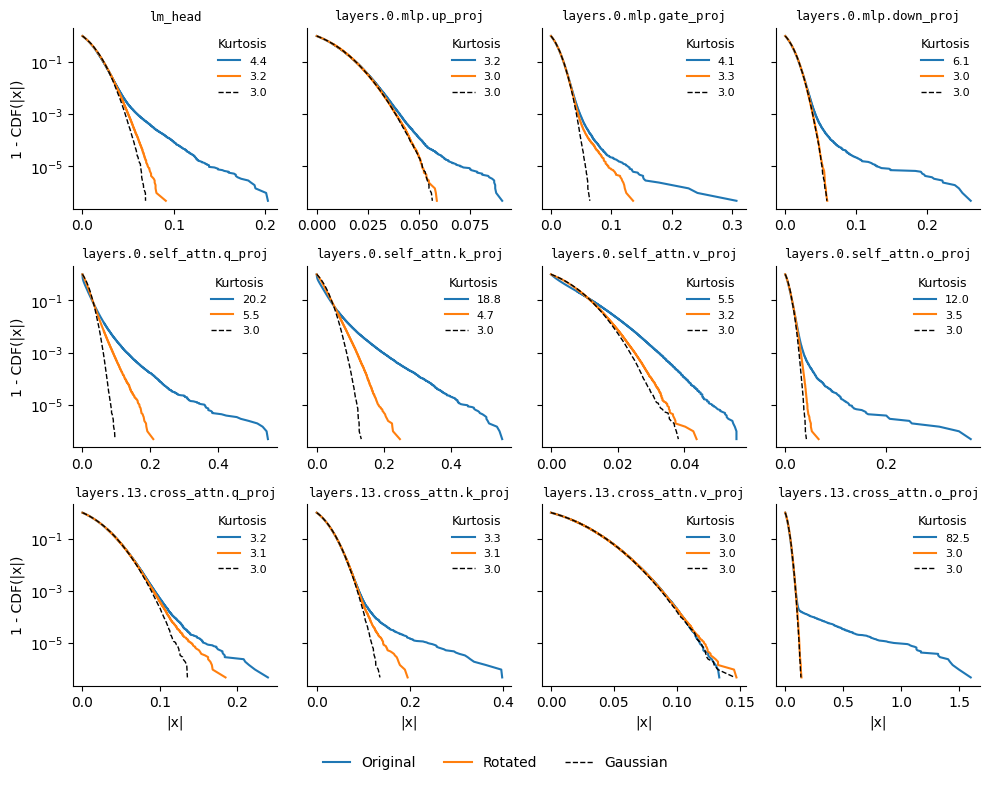

In [135]:
sample_count = 2**21
keys = [
    "language_model.lm_head.weight",
    "language_model.model.layers.0.mlp.up_proj.weight",
    "language_model.model.layers.0.mlp.gate_proj.weight",
    "language_model.model.layers.0.mlp.down_proj.weight",
    "language_model.model.layers.0.self_attn.q_proj.weight",
    "language_model.model.layers.0.self_attn.k_proj.weight",
    "language_model.model.layers.0.self_attn.v_proj.weight",
    "language_model.model.layers.0.self_attn.o_proj.weight",
    "language_model.model.layers.13.cross_attn.q_proj.weight",
    "language_model.model.layers.13.cross_attn.k_proj.weight",
    "language_model.model.layers.13.cross_attn.v_proj.weight",
    "language_model.model.layers.13.cross_attn.o_proj.weight",
]

torch.manual_seed(123)
rotation = torch.nn.init.orthogonal_(torch.empty(4096, 4096, device=p.device)).to(p.dtype)
ncols = torch.tensor(len(keys)).sqrt().ceil().int().item()
nrows = (len(keys) + ncols - 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(2.5*ncols, 2.5*nrows), squeeze=False, sharey=True)
for key, ax in zip(keys, axs.flatten()):
    p = model.state_dict()[key].detach().cuda()
    if any(s in key for s in ["o_proj", "down_proj"]):
        qp = rotation.T @ p
    else:
        qp = p @ rotation

    v = p.to(torch.float32).flatten()
    v = v[torch.randperm(v.size(0), device=v.device)[: sample_count]]
    kurtosis = ((p - p.mean()).pow(4).mean() / (p.var() ** 2))
    ax.plot(torch.sort(v.abs())[0].cpu(), 1 - torch.arange(0, v.size(0)) / v.size(0), label=f"{kurtosis:.1f}")

    v = qp.to(torch.float32).flatten()
    v = v[torch.randperm(v.size(0), device=v.device)[: sample_count]]
    kurtosis = ((qp - qp.mean()).pow(4).mean() / (qp.var() ** 2))
    ax.plot(torch.sort(v.abs())[0].cpu(), 1 - torch.arange(0, v.size(0)) / v.size(0), label=f"{kurtosis:.1f}")

    g = torch.randn_like(v).mul(v.std())
    kurtosis = ((g - g.mean()).pow(4).mean() / (g.var() ** 2))
    ax.plot(torch.sort(g.abs())[0].cpu(), 1 - torch.arange(0, g.size(0)) / g.size(0),
            color="k", ls="--", lw=1, label=f"{kurtosis:.1f}")

    ax.set_title(key.replace("language_model.", "").replace("model.", "").replace(".weight", ""), fontsize=9, fontfamily="monospace")
    ax.set_yscale("log")
    ax.legend(loc="upper right", fontsize=8, frameon=False, title="Kurtosis", title_fontsize=9)
for ax in axs.flatten()[len(keys):]:
    ax.remove()
for ax in axs[:, 0]:
    ax.set_ylabel("1 - CDF(|x|)")
for ax in axs[-1, :]:
    ax.set_xlabel("|x|")
fig.legend(axs[0, 0].lines, ["Original", "Rotated", "Gaussian"], loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False)
fig.tight_layout()